In [1]:
import os
import sys
import time
import datetime
import pickle
import numpy as np
import pandas as pd 
# Add src to path
src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from pytensor.graph.op import Op
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap



In [2]:
monk_data_1 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/empirical_data/behav_table_1.csv")
monk_data_1.sort_values(by='trialNum', ascending=True, inplace=True)
monk_data_1

,trialNum,lVal,rVal,firstVal,secondVal,chosenVal,leftChosen,firstChosen,liftRT,reachRT,firstIsLeft,firstIsRight,secondIsLeft,secondIsRight,firstFixLat,secondFixLat,thirdFixLat,firstFixDur,secondFixDur,thirdFixDur
308,1,3,1,3,1,1,0,0,0.757170,0.172254,1,0,0,1,0.162,0.410,NaN,0.188,0.644,NaN
412,2,4,3,4,3,4,1,1,0.747137,0.150739,1,0,0,1,0.168,0.420,0.636,0.192,0.156,0.576
153,3,2,4,2,4,4,0,0,0.747201,0.151524,1,0,0,1,0.134,0.402,NaN,0.212,0.916,NaN
361,4,3,3,3,3,3,1,1,0.947236,0.141216,1,0,0,1,0.158,0.386,0.758,0.176,0.328,0.688
525,5,5,5,5,5,5,0,1,1.076900,0.164868,0,1,1,0,0.142,0.370,0.882,0.188,0.456,0.656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,583,4,2,2,4,4,1,0,0.777188,0.174139,0,1,1,0,0.171,0.423,NaN,0.208,0.656,NaN
306,584,4,3,3,4,4,1,0,0.877214,0.154446,0,1,1,0,0.173,0.401,NaN,0.184,0.780,NaN
411,585,2,3,3,2,3,0,1,1.027219,0.175890,0,1,1,0,0.117,0.405,0.765,0.228,0.316,0.552
307,586,3,4,3,4,4,0,0,0.867116,0.176373,1,0,0,1,0.149,0.417,NaN,0.220,1.048,NaN


In [3]:
# Transform data csv 

DATA_TYPE = np.float64
a = 2.0 
b = 0.3
x0 = -0.2
kappa = 0.5 
eta = 0.7

max_d = 12

r1 = monk_data_1['lVal'].to_numpy(dtype=DATA_TYPE) # r1 is left value 
r2 = monk_data_1['rVal'].to_numpy(dtype=DATA_TYPE) # r2 is right value 

# Determine length data 
third_present = monk_data_1['thirdFixLat'].notna().to_numpy()
length_data = np.where(third_present, 3, 2).astype(np.int32)

t0 = monk_data_1["firstFixLat"].to_numpy(dtype=DATA_TYPE)
t1 = monk_data_1["secondFixLat"].to_numpy(dtype=DATA_TYPE)
t2 = monk_data_1["thirdFixLat"].fillna(0).to_numpy(dtype=DATA_TYPE)

# Build padded saccade array 
sacc = np.zeros((len(monk_data_1), max_d), dtype=DATA_TYPE)
sacc[:,0] = 0.0 
sacc[:,1] = t1-t0
sacc[third_present, 2] = t2[third_present]-t0[third_present]

# Build flag data -- 0 if first fixation is left, 1 if first fixation is right
first_is_left = monk_data_1['firstIsLeft'].to_numpy().astype(int)
flag_data = np.where(first_is_left == 1,0,1).astype(np.int32)

rt_raw = monk_data_1["liftRT"].to_numpy(dtype=DATA_TYPE)
rt = rt_raw - t0 # shift RT to be relative to first fixation 
left_chosen = monk_data_1["leftChosen"].to_numpy().astype(int)
choice = np.where(left_chosen == 1, 1.0, -1.0).astype(np.int32)

mu1 = kappa * (r1 - eta * r2) 
mu2 = kappa * (eta * r1 - r2)

In [ ]:
sacc

array([[0.   , 0.248, 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.252, 0.468, ..., 0.   , 0.   , 0.   ],
       [0.   , 0.268, 0.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.   , 0.288, 0.648, ..., 0.   , 0.   , 0.   ],
       [0.   , 0.268, 0.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.26 , 0.6  , ..., 0.   , 0.   , 0.   ]], shape=(587, 12))

In [5]:
from efficient_fpt.multi_stage_cy import compute_loss_parallel, print_num_threads

print_num_threads()
num_iter = 5 
start_time = time.time()
for _ in range(num_iter):
    loss = compute_loss_parallel(
        mu1, 
        mu2, 
        rt, 
        choice,
        flag_data,
        sacc,
        length_data, 
        max_d, 
        1, 
        a, 
        b,
        x0,
        num_threads=48,
    )
    print(loss)
end_time = time.time()
print(f"avg time per iter:", (end_time - start_time) / num_iter)

Number of available threads: 12
0.9931647896991385
0.993164789699139
0.9931647896991387
0.9931647896991385
0.9931647896991385
avg time per iter: 0.006351900100708008


# PyMC Bayesian Inference using JAX Likelihood

In [ ]:
# Configuration
sigma = 1.0          # Fixed noise parameter (unidentifiable with other params)
M = float(np.max(rt))  # Max reaction time (for boundary constraint)
num_data = len(rt)   # 587 trials

TRUNC_NUM = 6        # Series truncation (optimal for JAX/XLA)
N_DRAWS = 500       # Posterior draws per chain
N_TUNE = 500         # Warmup/tuning steps
N_CHAINS = 2         # Number of MCMC chains
RANDOM_SEED = 42

print(f"Trials: {num_data}, Max RT: {M:.4f}, max_d: {max_d}")
print(f"Sampling: {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")

Trials: 587, Max RT: 1.3751, max_d: 12
Sampling: 500 draws, 500 tune, 2 chains


In [7]:
# Convert data to JAX arrays
from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely

jax_rt = jnp.array(rt)
jax_choice = jnp.array(choice)
jax_d = jnp.array(length_data)
jax_r1 = jnp.array(r1)
jax_r2 = jnp.array(r2)
jax_flag = jnp.array(flag_data)
jax_sacc = jnp.array(sacc)

# Pre-compute safe saccade arrays (prevents NaN gradients)
jax_sacc_safe = vmap(lambda s, d: pad_sacc_array_safely(s, d, max_d))(jax_sacc, jax_d)

print(f"JAX arrays created. sacc_safe shape: {jax_sacc_safe.shape}")
print(f"JAX devices: {jax.devices()}")

JAX arrays created. sacc_safe shape: (587, 12)
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


In [8]:
# Define JAX likelihood functions

def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """
    Compute mu arrays for a single trial given parameters.
    
    For flag=0 (first fixation left):  [mu1, mu2, mu1, mu2, ...]
    For flag=1 (first fixation right): [mu2, mu1, mu2, mu1, ...]
    """
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    
    indices = jnp.arange(max_d)
    mu_array = jnp.where(
        (indices % 2) == flag,
        mu1,
        mu2
    )
    return mu_array


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Compute log-likelihood for a single trial."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe
    )
    
    return jnp.log(jnp.maximum(fptd, 1e-30))


def jax_loglik_batch(eta, kappa, a, b, x0):
    """
    Compute total log-likelihood for all trials.
    Closes over data arrays, sigma, max_d, TRUNC_NUM.
    """
    loglik_fn = vmap(
        lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
            rt, choice, d, r1, r2, flag, sacc_safe,
            eta, kappa, a, b, x0, sigma, max_d, TRUNC_NUM
        )
    )
    
    logliks = loglik_fn(jax_rt, jax_choice, jax_d, jax_r1, jax_r2, jax_flag, jax_sacc_safe)
    return jnp.sum(logliks)


# JIT compile likelihood and gradient
jax_loglik_jit = jit(jax_loglik_batch)
jax_grad_loglik = jit(grad(jax_loglik_batch, argnums=(0, 1, 2, 3, 4)))

# Warm up JIT (first call triggers XLA compilation)
print("Warming up JAX JIT compilation...")
t_jit_start = time.time()
ll_test = jax_loglik_jit(0.7, 0.5, 2.0, 0.3, -0.2)
_ = jax_grad_loglik(0.7, 0.5, 2.0, 0.3, -0.2)
t_jit_end = time.time()
print(f"JIT compilation: {t_jit_end - t_jit_start:.1f}s")
print(f"JAX log-likelihood at initial params: {float(ll_test):.4f}")

Warming up JAX JIT compilation...
JIT compilation: 8.8s
JAX log-likelihood at initial params: -582.9877


In [9]:
# PyTensor custom Ops with gradient support
from pytensor.link.jax.dispatch import jax_funcify


class LogLikeJAX(Op):
    """PyTensor Op wrapping the JAX likelihood function with gradients."""
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        loglik = float(self.loglik_fn(eta, kappa, a, b, x0))
        outputs[0][0] = np.array(loglik, dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,) = inputs
        (g_out,) = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """Gradient Op for the JAX likelihood."""
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        grad_array = np.array([float(g) for g in grads], dtype="float64")
        outputs[0][0] = grad_array


# Register JAX implementations for numpyro backend
@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        grads = grad_fn(eta, kappa, a, b, x0)
        return jnp.stack(grads)
    return grad_jax


# Instantiate the Op
jax_loglike_op = LogLikeJAX(jax_loglik_jit, jax_grad_loglik)

# Test: verify Op produces correct values
theta_test = np.array([0.7, 0.5, 2.0, 0.3, -0.2])
theta_sym = pt.dvector("theta")
ll_op_fn = pytensor.function([theta_sym], jax_loglike_op(theta_sym))
print(f"Op log-likelihood at test params: {ll_op_fn(theta_test):.4f}")

# Test gradient
grad_sym = pt.grad(jax_loglike_op(theta_sym), theta_sym)
grad_op_fn = pytensor.function([theta_sym], grad_sym)
print(f"Op gradients at test params: {grad_op_fn(theta_test)}")

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Op log-likelihood at test params: -582.9877
Op gradients at test params: [-243.11892166  836.95988154 -782.25798076  767.37029236  142.18677525]


In [10]:
# Build PyMC model
with pm.Model() as model:
    # eta: attention discount factor in [0, 1]
    eta = pm.Beta("eta", alpha=2.0, beta=2.0)
    
    # kappa: drift scaling (positive)
    kappa = pm.Gamma("kappa", alpha=2.0, beta=4.0)
    
    # a: initial boundary separation (positive)
    a_param = pm.Gamma("a", alpha=4.0, beta=2.0)
    
    # b: collapse rate, constrained so boundary stays positive at max RT
    b_raw = pm.Beta("b_raw", alpha=2.0, beta=2.0)
    b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)
    
    # x0: starting position, constrained to [-a, a]
    x0_raw = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
    x0_param = pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)
    
    # Stack parameters and add custom likelihood
    theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
    pm.Potential("loglik", jax_loglike_op(theta))

print("PyMC model built successfully.")
print(model.point_logps())

PyMC model built successfully.
{'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-257.1)}


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


In [11]:
# Run NUTS sampling via numpyro backend
print(f"Configuration: {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started at: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model:
    t_start = time.perf_counter()
    trace = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    t_sample = time.perf_counter() - t_start

print(f"\nFinished at: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total sampling time: {t_sample:.1f} s")
print(f"Time per sample: {t_sample / (N_DRAWS * N_CHAINS) * 1000:.1f} ms")

Configuration: 500 draws, 500 tune, 2 chains
Started at: 23:45:02


Running chain 1: 100%|██████████| 1000/1000 [07:54<00:00,  2.11it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics



Finished at: 23:53:00
Total sampling time: 477.5 s
Time per sample: 477.5 ms


In [12]:
# Convergence diagnostics
params = ['eta', 'kappa', 'a', 'b', 'x0']
print(az.summary(trace, var_names=params))

print(f"\nEffective samples per second:")
for param in params:
    ess = float(az.ess(trace, var_names=[param])[param])
    print(f"  {param}: ESS={ess:.0f}, ESS/s={ess/t_sample:.1f}")

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.015  0.010   0.001    0.034      0.000    0.000     912.0     502.0   
kappa  1.159  0.040   1.080    1.232      0.002    0.001     710.0     607.0   
a      3.007  0.086   2.859    3.184      0.003    0.003     776.0     715.0   
b      2.067  0.060   1.945    2.171      0.002    0.002     799.0     693.0   
x0     0.055  0.035  -0.009    0.117      0.001    0.001    1017.0     665.0   

       r_hat  
eta      1.0  
kappa    1.0  
a        1.0  
b        1.0  
x0       1.0  

Effective samples per second:
  eta: ESS=912, ESS/s=1.9
  kappa: ESS=710, ESS/s=1.5
  a: ESS=776, ESS/s=1.6
  b: ESS=799, ESS/s=1.7
  x0: ESS=1017, ESS/s=2.1


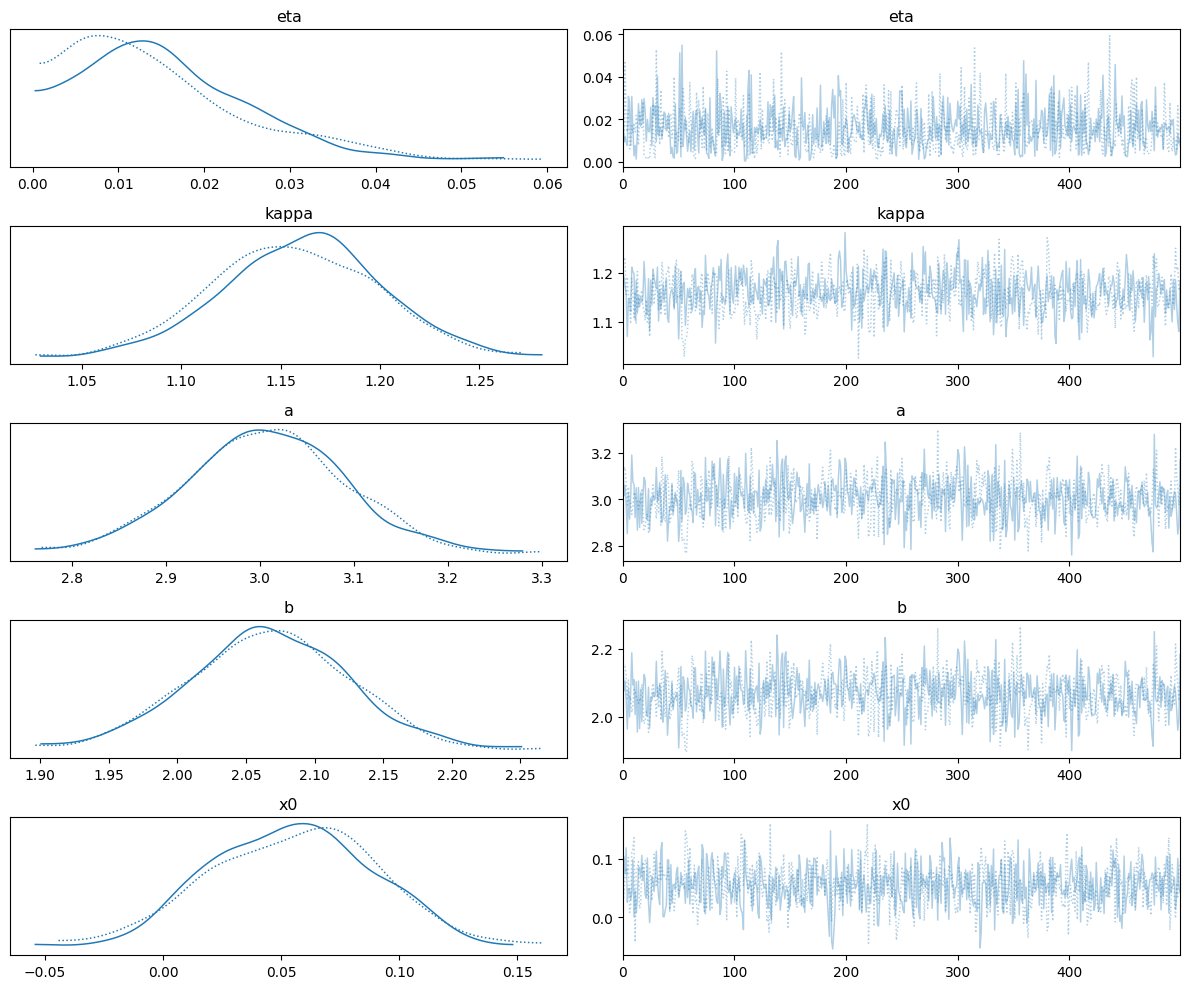

In [13]:
# Trace plots (visual convergence check)
az.plot_trace(trace, var_names=params)
plt.tight_layout()
plt.show()

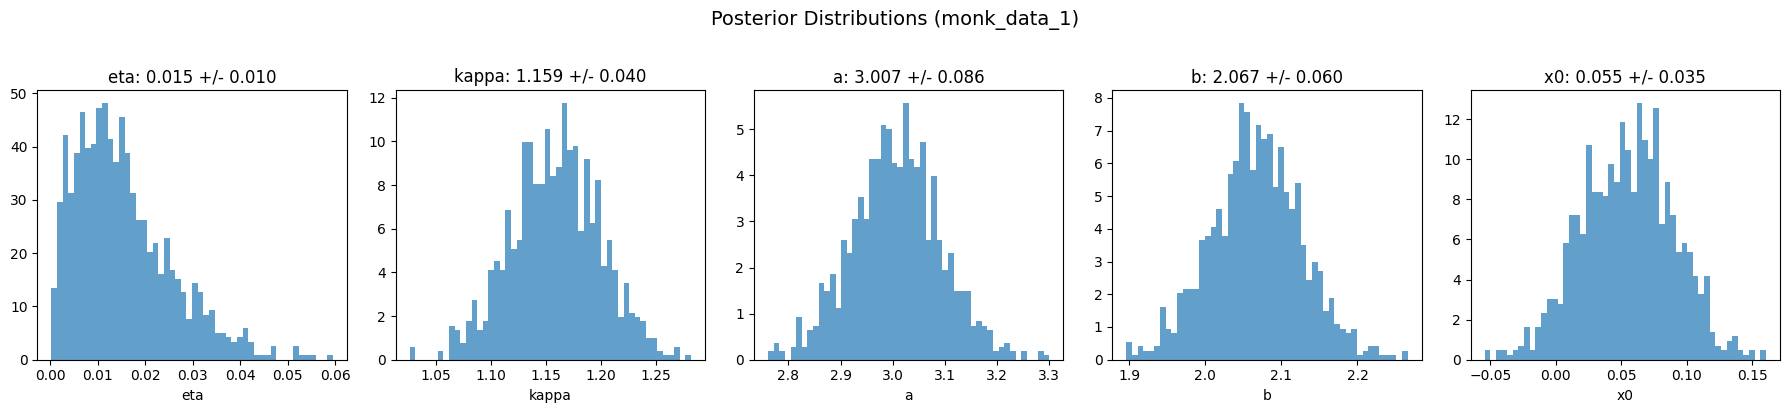

In [14]:
# Posterior distributions
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, param in enumerate(params):
    ax = axes[i]
    samples = trace.posterior[param].values.flatten()
    ax.hist(samples, bins=50, density=True, alpha=0.7)
    ax.set_xlabel(param)
    ax.set_title(f'{param}: {np.mean(samples):.3f} +/- {np.std(samples):.3f}')
plt.suptitle('Posterior Distributions (monk_data_1)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

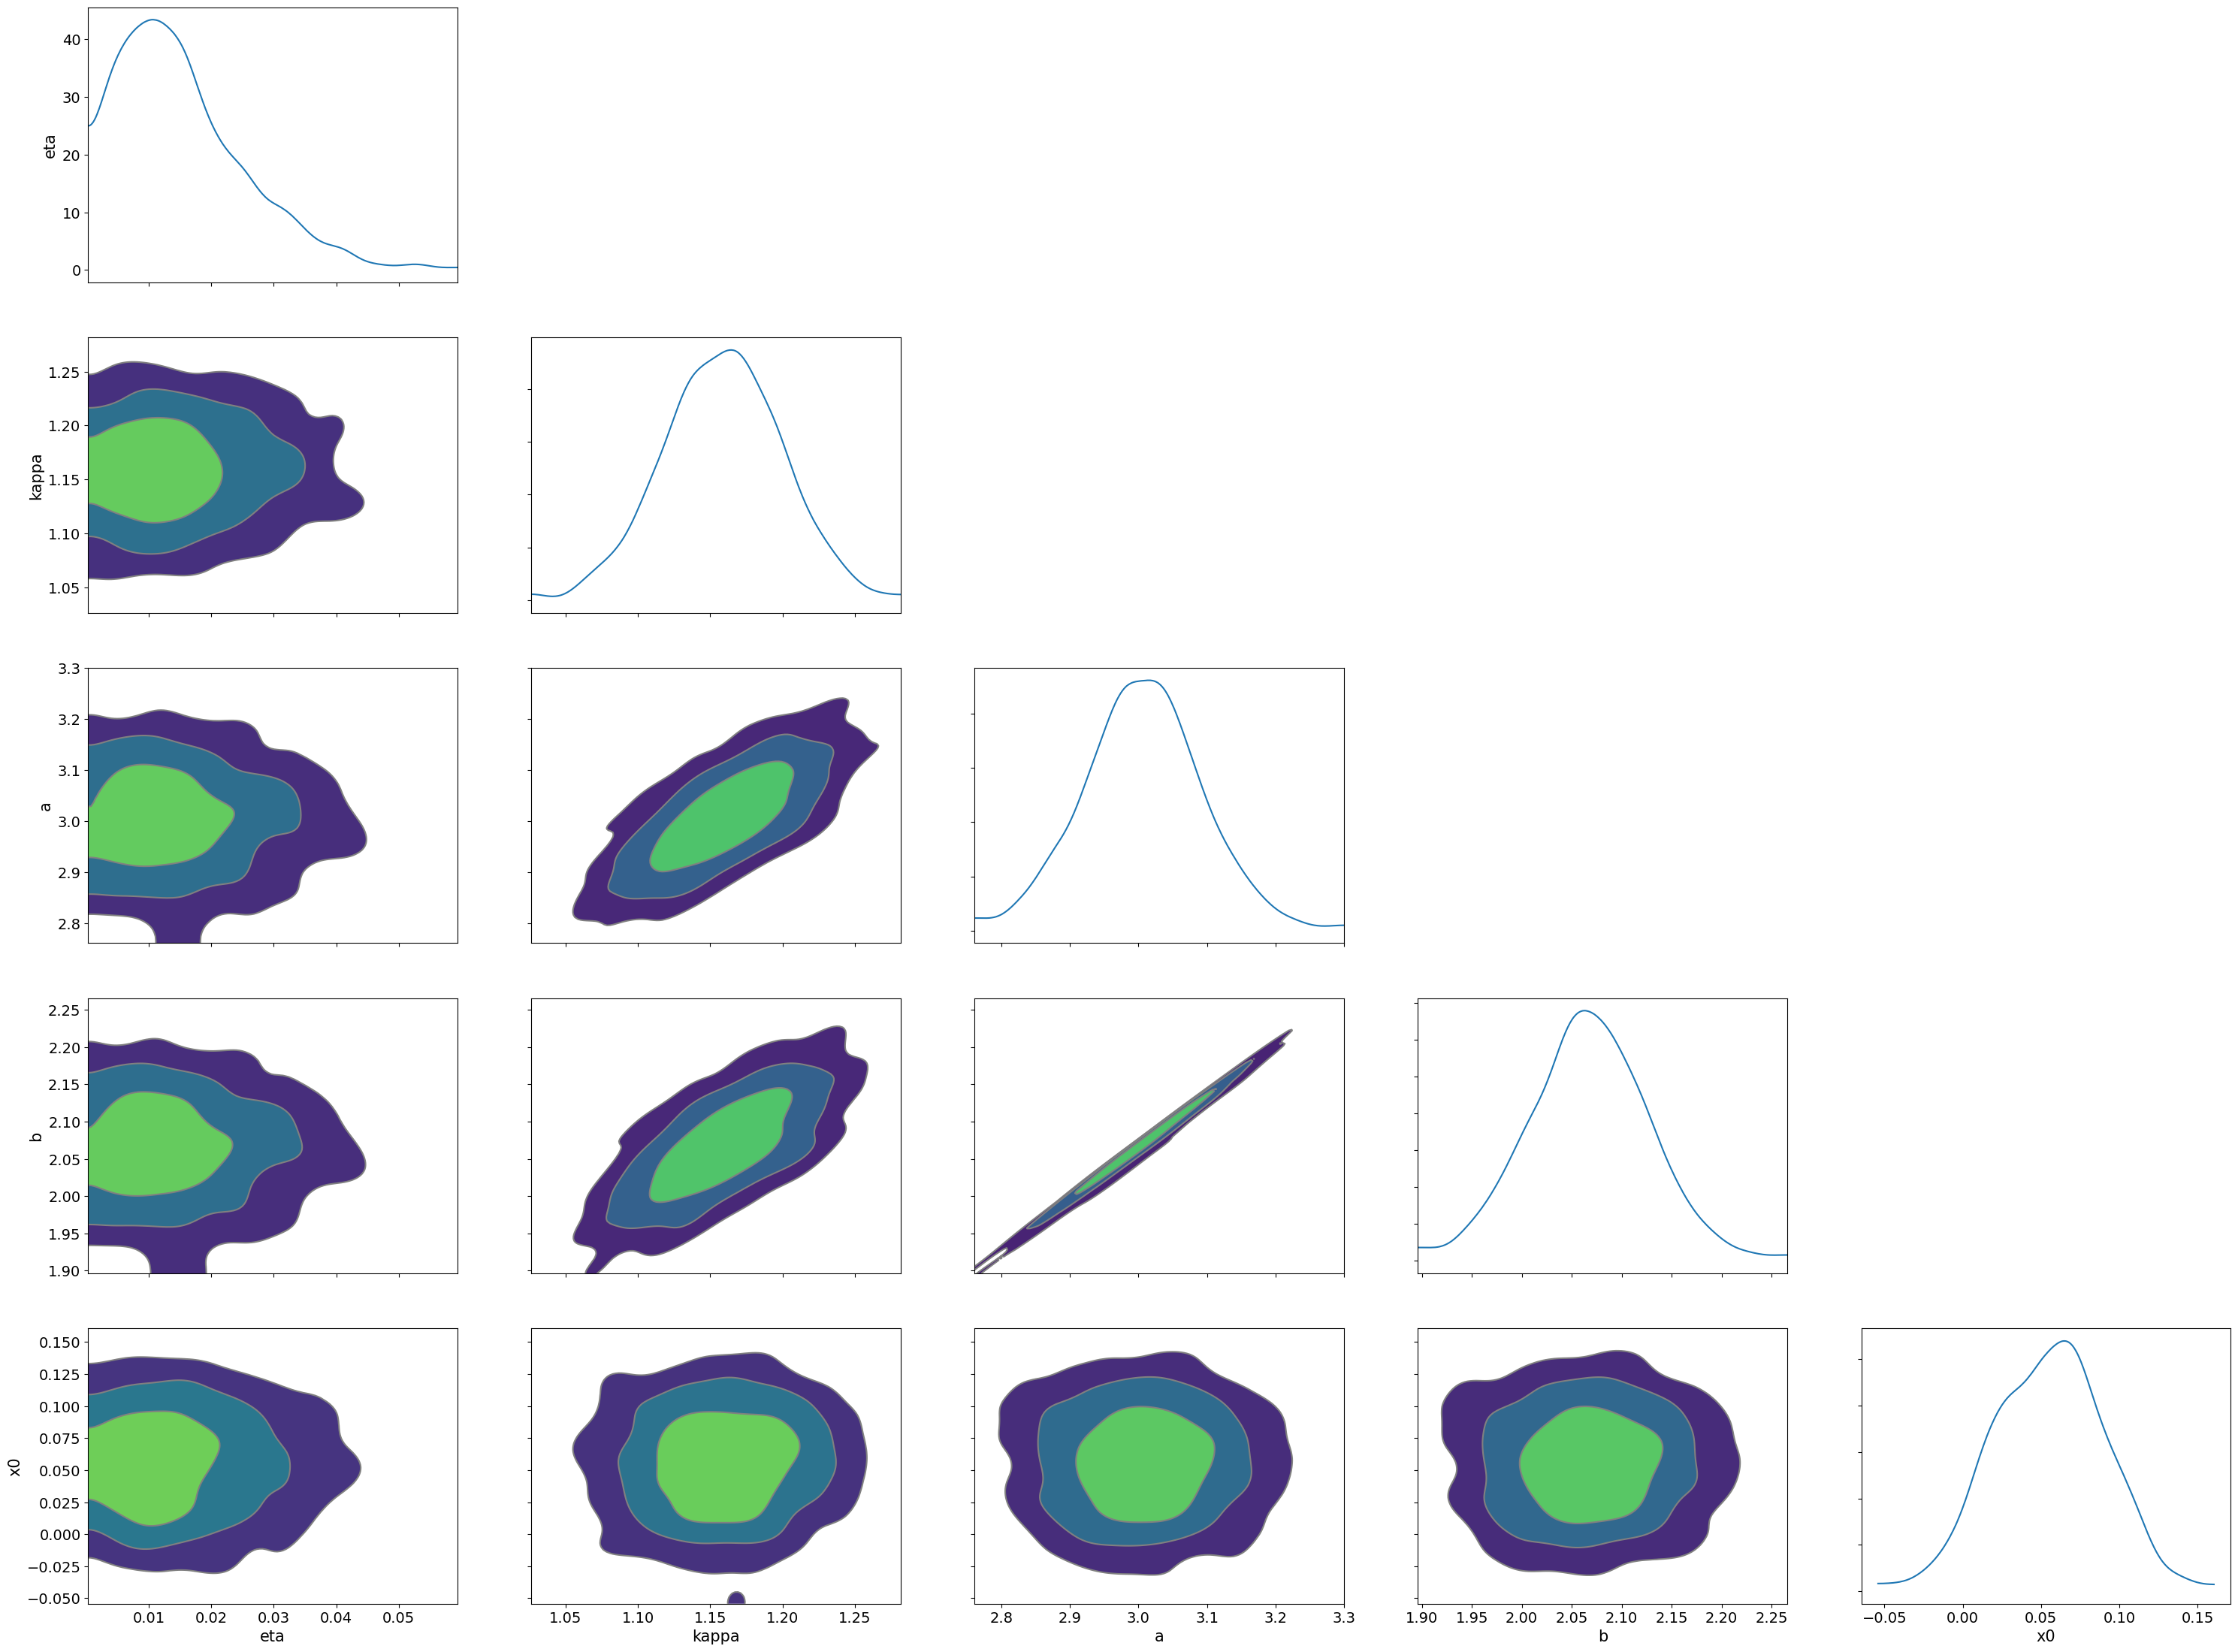

In [15]:
# Pair plot (posterior correlations)
az.plot_pair(trace, var_names=params, kind='kde', marginals=True)
plt.show()

Posterior means:
  eta=0.0153, kappa=1.1586, a=3.0068, b=2.0670, x0=0.0549
  Sim 1: 587/587 terminated, choice +1: 0.479

Total simulated: 587/587 terminated


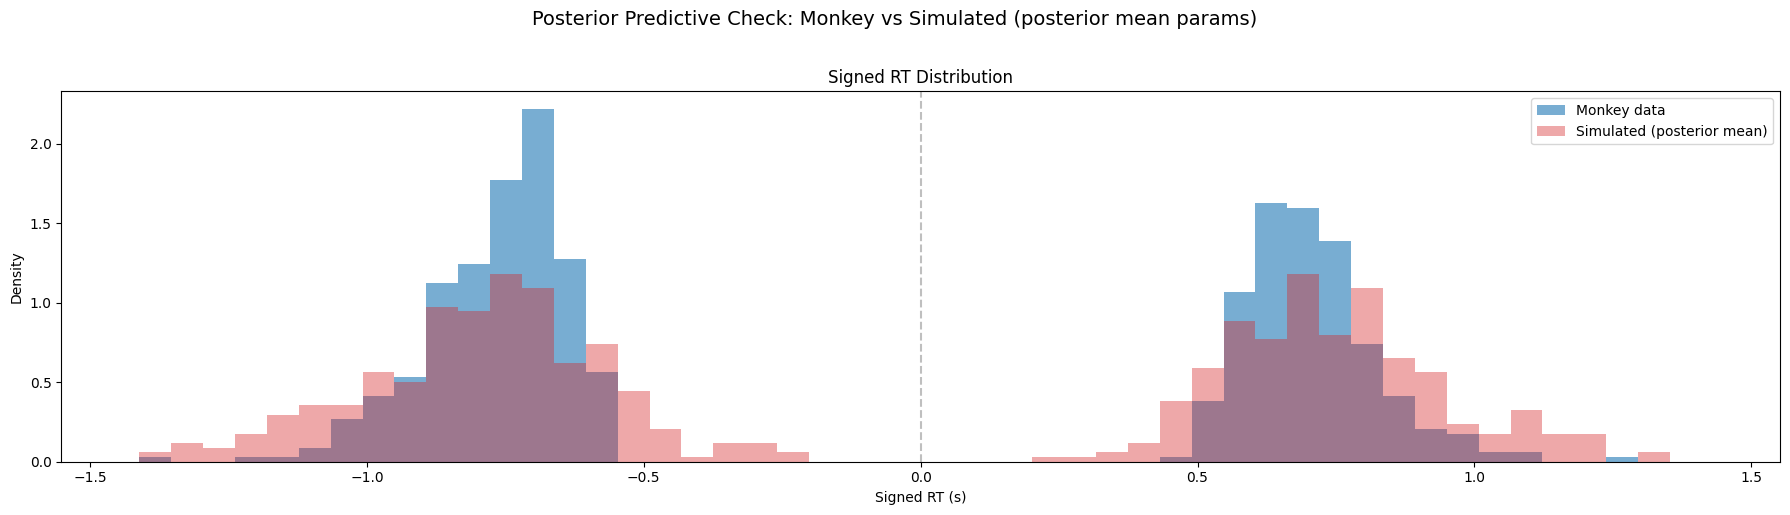


Summary statistics:
                             Monkey    Simulated
  Mean RT (s)                0.7394       0.7701
  Median RT (s)              0.7181       0.7538
  Std RT (s)                 0.1254       0.2079
  P(choice=+1)               0.4480       0.4787
  N trials                      587          587


In [26]:
# Forward simulate data from posterior means for PPC 
# Forward simulate from posterior means using empirical trial structure
from efficient_fpt.addm import _build_mu_data_padded
from efficient_fpt.addm_simulator_cy import simulate_addm_batch_cy

# Extract posterior means
post_eta = float(trace.posterior['eta'].mean())
post_kappa = float(trace.posterior['kappa'].mean())
post_a = float(trace.posterior['a'].mean())
post_b = float(trace.posterior['b'].mean())
post_x0 = float(trace.posterior['x0'].mean())

print(f"Posterior means:")
print(f"  eta={post_eta:.4f}, kappa={post_kappa:.4f}, a={post_a:.4f}, b={post_b:.4f}, x0={post_x0:.4f}")

# Compute mu1/mu2 per trial using empirical r1/r2 + posterior params
sim_mu1 = post_kappa * (r1 - post_eta * r2)
sim_mu2 = post_kappa * (post_eta * r1 - r2)

# Build padded mu array (n_trials, max_d) with alternating drift per fixation
sim_mu_data = _build_mu_data_padded(
    sim_mu1.astype(np.float64),
    sim_mu2.astype(np.float64),
    length_data,
    flag_data,
    max_d,
)

# Simulation parameters
dt = 1e-4
max_t = 10.0
budget_time = min(post_a / post_b, max_t) if post_b > 0 else max_t
budget_steps = int(budget_time / dt) + 1
n_sims = 1  # number of simulated datasets for variability

rng = np.random.default_rng(123)
all_sim_rts = []
all_sim_choices = []

for i in range(n_sims):
    gaussian_data = np.ascontiguousarray(
        rng.standard_normal((num_data, budget_steps), dtype=np.float64)
    )
    sim_rt, sim_choice = simulate_addm_batch_cy(
        np.ascontiguousarray(sim_mu_data),
        np.ascontiguousarray(sacc),
        np.ascontiguousarray(length_data),
        sigma, post_a, post_b, post_x0, dt, budget_time,
        gaussian_data,
    )
    all_sim_rts.append(np.array(sim_rt))
    all_sim_choices.append(np.array(sim_choice))
    terminated = np.array(sim_rt) > 0
    print(f"  Sim {i+1}: {terminated.sum()}/{num_data} terminated, "
          f"choice +1: {(np.array(sim_choice)[terminated]==1).mean():.3f}")

# Concatenate all simulations for plotting
sim_rts_all = np.concatenate(all_sim_rts)
sim_choices_all = np.concatenate(all_sim_choices)
sim_terminated = sim_rts_all > 0
sim_rts_valid = sim_rts_all[sim_terminated]
sim_choices_valid = sim_choices_all[sim_terminated]

print(f"\nTotal simulated: {sim_terminated.sum()}/{len(sim_rts_all)} terminated")

# Posterior predictive check: Empirical vs Simulated RT/Choice distributions
emp_terminated = rt > 0
emp_rt = rt[emp_terminated]
emp_choice = choice[emp_terminated]

# Signed RT: positive = upper boundary (left chosen), negative = lower boundary
emp_signed_rt = emp_rt * emp_choice
sim_signed_rt = sim_rts_valid * sim_choices_valid

fig, axes = plt.subplots(1, 1, figsize=(18, 5))

# --- Panel 1: Signed RT distributions (combined) ---
ax = axes
bins_signed = np.linspace(-max(emp_rt.max(), sim_rts_valid.max()),
                           max(emp_rt.max(), sim_rts_valid.max()), 50)
ax.hist(emp_signed_rt, bins=bins_signed, density=True, alpha=0.6,
        label='Monkey data', color='#1f77b4')
ax.hist(sim_signed_rt, bins=bins_signed, density=True, alpha=0.4,
        label='Simulated (posterior mean)', color='#d62728')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Signed RT (s)')
ax.set_ylabel('Density')
ax.set_title('Signed RT Distribution')
ax.legend()

# # --- Panel 2: Upper boundary (choice = +1, left chosen) ---
# ax = axes[1]
# bins_rt = np.linspace(0, max(emp_rt.max(), sim_rts_valid.max()), 40)
# emp_upper = emp_rt[emp_choice == 1]
# sim_upper = sim_rts_valid[sim_choices_valid == 1]
# ax.hist(emp_upper, bins=bins_rt, density=True, alpha=0.6,
#         label=f'Monkey (n={len(emp_upper)})', color='#1f77b4')
# ax.hist(sim_upper, bins=bins_rt, density=True, alpha=0.4,
#         label=f'Simulated (n={len(sim_upper)})', color='#d62728')
# ax.set_xlabel('RT (s)')
# ax.set_ylabel('Density')
# ax.set_title('Upper Boundary (choice = +1)')
# ax.legend()

# # --- Panel 3: Lower boundary (choice = -1, right chosen) ---
# ax = axes[2]
# emp_lower = emp_rt[emp_choice == -1]
# sim_lower = sim_rts_valid[sim_choices_valid == -1]
# ax.hist(emp_lower, bins=bins_rt, density=True, alpha=0.6,
#         label=f'Monkey (n={len(emp_lower)})', color='#1f77b4')
# ax.hist(sim_lower, bins=bins_rt, density=True, alpha=0.4,
#         label=f'Simulated (n={len(sim_lower)})', color='#d62728')
# ax.set_xlabel('RT (s)')
# ax.set_ylabel('Density')
# ax.set_title('Lower Boundary (choice = -1)')
# ax.legend()

fig.suptitle('Posterior Predictive Check: Monkey vs Simulated (posterior mean params)',
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary statistics:")
print(f"  {'':20s} {'Monkey':>12s} {'Simulated':>12s}")
print(f"  {'Mean RT (s)':20s} {emp_rt.mean():12.4f} {sim_rts_valid.mean():12.4f}")
print(f"  {'Median RT (s)':20s} {np.median(emp_rt):12.4f} {np.median(sim_rts_valid):12.4f}")
print(f"  {'Std RT (s)':20s} {emp_rt.std():12.4f} {sim_rts_valid.std():12.4f}")
print(f"  {'P(choice=+1)':20s} {(emp_choice==1).mean():12.4f} {(sim_choices_valid==1).mean():12.4f}")
print(f"  {'N trials':20s} {len(emp_rt):12d} {len(sim_rts_valid):12d}")


In [17]:
# Save results
# trace.to_netcdf("empirical_monk1_trace.nc")

# results = {
#     'trace': trace,
#     'config': {
#         'N_DRAWS': N_DRAWS, 'N_TUNE': N_TUNE, 'N_CHAINS': N_CHAINS,
#         'TRUNC_NUM': TRUNC_NUM, 'sigma': sigma, 'num_data': num_data,
#     },
#     'timing': {'total_seconds': t_sample},
# }
# with open("empirical_monk1_results.pkl", "wb") as f:
#     pickle.dump(results, f)

# print("Results saved to empirical_monk1_trace.nc and empirical_monk1_results.pkl")